# **Assignment 4 - Variational Autoencoders**

In this assignment, we will train a model to produce new human faces with variational autoencoders (VAEs).
Variational autoencoders let us design complex generative models of data, and fit them to large datasets. They can generate images of fictional celebrity faces (as we'll do in this assignment), high-resolution digital artwork and many more tasks. These models also yield state-of-the-art machine learning results in image generation and reinforcement learning. Variational autoencoders (VAEs) were defined in 2013 by Kingma and Wellings [1].

In this assignment, you will build, train and analyze a VAE with the CelebA dataset. You will analyze how well images can be reconstructed from the lower dimensional representations and try to generate images that look similar to the images in the CelebA dataset.

[1] Kingma, Diederik P., and Max Welling. "Auto-encoding variational bayes." arXiv preprint arXiv:1312.6114 (2013).


# **Section 1: Variational Autoencoders**


Let us recall the structure of the variational autoencoder:

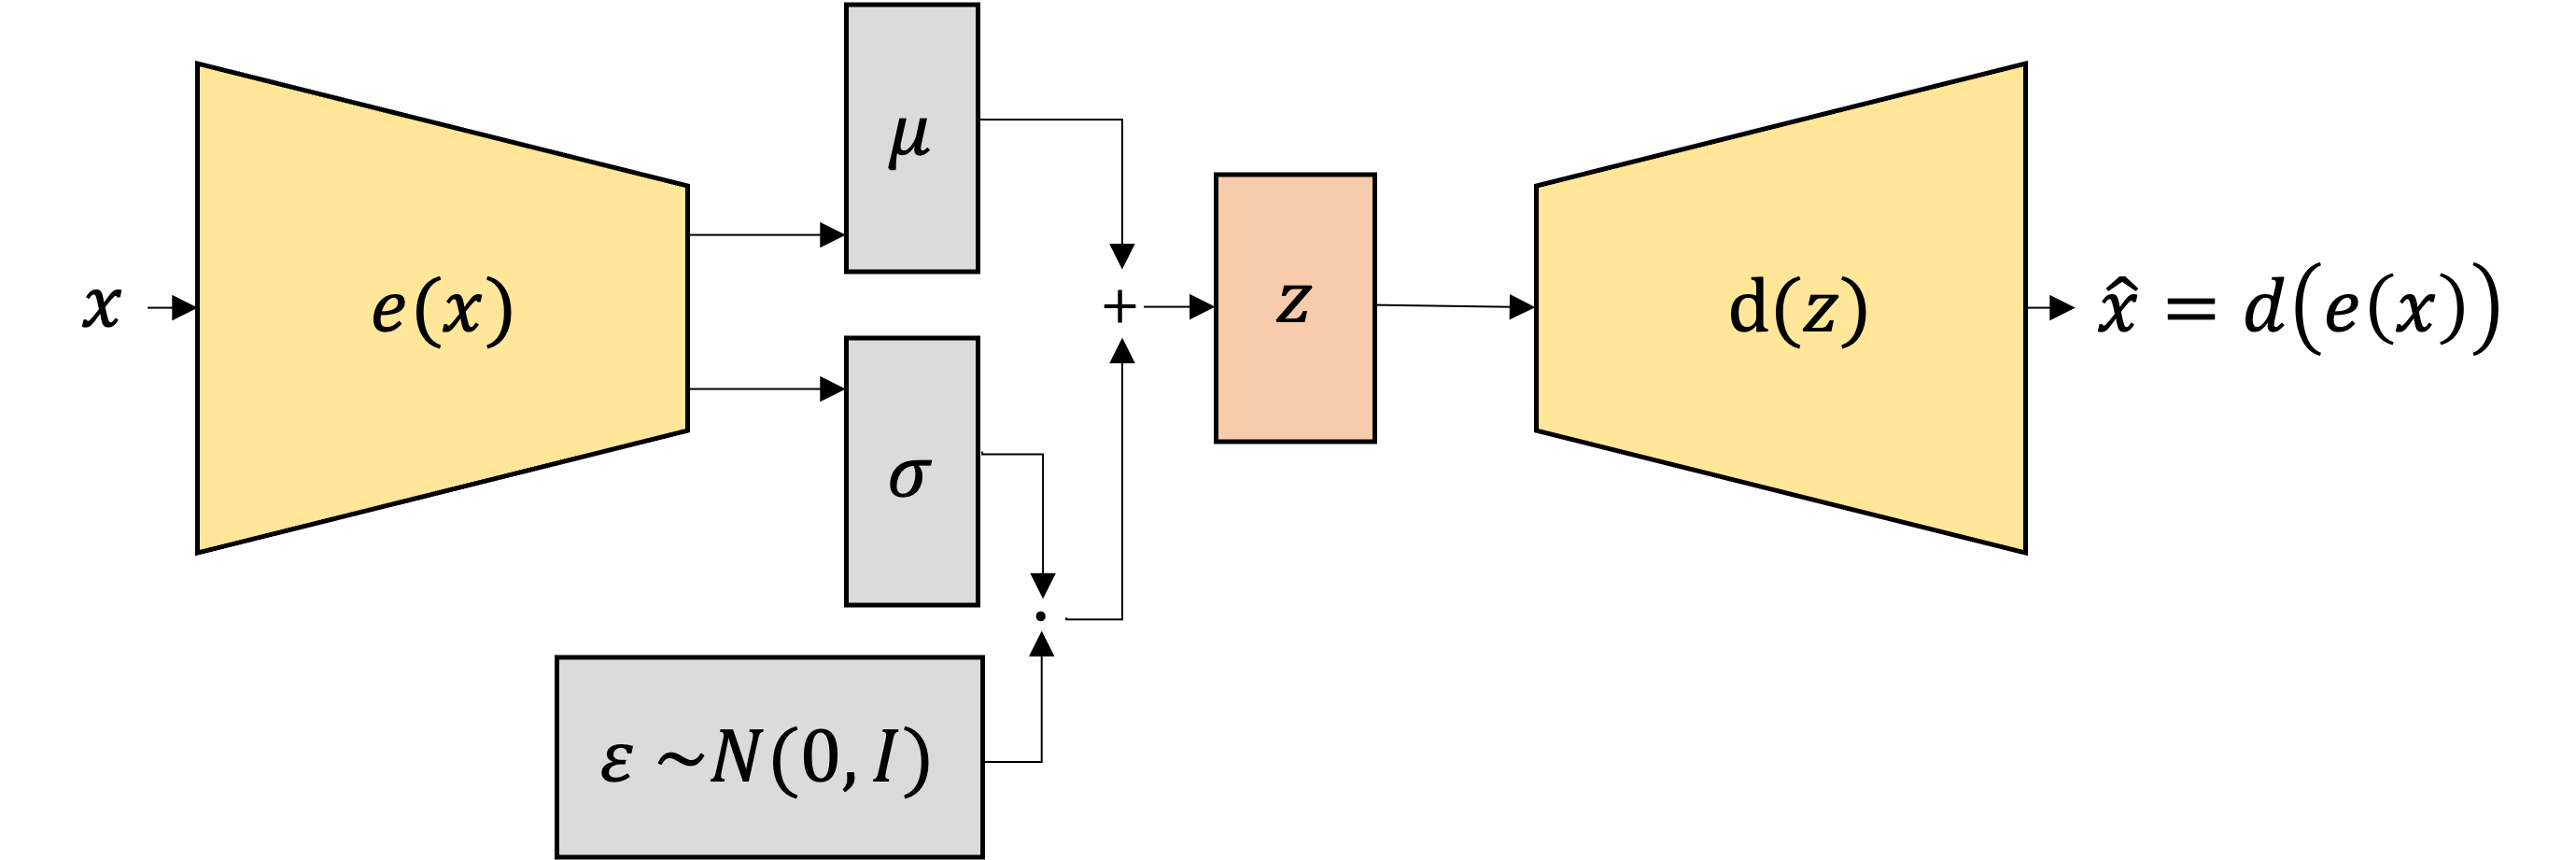

**Imports**

Before we begin, we import the needed libraries.


You may modify the starter code as you see fit, including changing the signatures of
functions and adding/removing helper functions. However, please make sure that we can understand what you are doing and why.

In [1]:
from torchvision import datasets
from torchvision import transforms
from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as nnF
from torchvision.utils import make_grid
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import torchvision.transforms.functional as F
from torchvision.utils import make_grid
import os
import zipfile

%pip install wget
import wget

# use GPU for computation if possible: Go to RUNTIME -> CHANGE RUNTIME TYPE -> GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=2edc77ed36d4c73644f4279f3828e5e6d48d3cd6d9d721a0c932fb9490605e15
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


Connect to your Google Drive, select the path in your drive for saving the checkpoints of your model, which we will train later.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

# Path to save the dataset.
PATH_TO_SAVE_MODEL = '/content/gdrive/MyDrive/Intro_to_Deep_Learning/Assignment4'

Mounted at /content/gdrive


Define random seeds in order to reproduce your results.

In [3]:
# TO DO: Set random seeds - to your choice
torch.manual_seed(43)         # Insert any integer
torch.cuda.manual_seed(43)    # Insert any integer

## Question 1. Basic Principles (10 %)




### Part (a) -- 3%

What is the difference between deterministic autoencoder we saw in class and the variational autoencoder?

In [4]:
# A deterministic autoencoder (AE) maps an input to a single fixed latent code,
# while a variational autoencoder (VAE) maps an input to a distribution over
# latent codes and is trained to make that distribution match a chosen prior so
# you can reliably generate --new-- samples.

### Part (b) -- 3%
In which manner Variational Autoencoder is trained? Explain.


In [5]:
# A VAE is trained with a loss that has two parts: it penalizes poor
# reconstruction of the input, and it regularizes the latent space by pushing
# the encoder’s latent distribution to stay close to a simple prior.
# Sampling is implemented in a differentiable way so gradients can flow through
# the encoder during backpropagation.


### Part (c) -- 4%

In class we saw another generative model, known as generative adversarial network (GAN). What are the differences in terms of task objective between GANs and VAEs? Give an example for a task which a VAE is more suitable than GAN, and vice versa.

In [6]:
# Differences in terms of task objective:
# A VAE is trained to reconstruct inputs while regularizing the latent space to
# match a simple prior, giving a structured, smooth latent representation.
# A GAN is trained with an adversarial game: the generator tries to fool a
# discriminator, focusing on making samples indistinguishable from real data.

# Example for a task which a VAE is more suitable than GAN:
# Cleaning up a blurry photo while keeping a stable “essence” of the scene (smooth changes when you tweak the code).

# Example for a task which a GAN is more suitable than VAE:
# Creating realistic-looking face Images for a profile picture (not a real person, just realistic).

## Question 2. Data (15 %)

In this assignement we are using the CelebFaces Attributes Dataset (CelebA).

The CelebA dataset, as its name suggests, is comprised of celebrity faces. The images cover large pose variations, background clutter, diverse people, supported by a large quantity of images and rich annotations. This data was originally collected by researchers at MMLAB, The Chinese University of Hong Kong.

**Overall**

- 202,599 number of face images of various celebrities
- 10,177 unique identities, but names of identities are not given
- 40 binary attribute annotations per image
- 5 landmark locations

In this torchvision version of the dataset, each image is in the shape of
$[218,178,3]$ and the values are in $[0,1]$.

Here, you will download the dataset to the Google Colab disk. It is highly recommended not to download the dataset to your own Google Drive account since it is time consuming.

In [7]:
data_path = "/content/datasets"

base_url = "https://ftp.mi.fu-berlin.de/pub/cmb-data/celeba"

file_list = [
    "img_align_celeba.zip",
    "list_attr_celeba.txt",
    "identity_CelebA.txt",
    "list_bbox_celeba.txt",
    "list_landmarks_align_celeba.txt",
    "list_eval_partition.txt",
]

# Path to folder with the dataset
dataset_folder = f"{data_path}/celeba"
os.makedirs(dataset_folder, exist_ok=True)

for file in file_list:
    url = f"{base_url}/{file}"
    if not os.path.exists(f"{dataset_folder}/{file}"):
        wget.download(url, f"{dataset_folder}/{file}")

with zipfile.ZipFile(f"{dataset_folder}/img_align_celeba.zip", "r") as ziphandler:
    ziphandler.extractall(dataset_folder)

### Part (a) -- 5%

Apply transformations:

The data is given as PIL (Python Imageing Library) images. Since we are working with PyTorch, we wish to apply transformations to the data in order to process it properly.

Here you should apply transformations to the data. There are many kinds of transformations which can be found here: https://pytorch.org/vision/stable/transforms.html. Note that transformations can be chained together using Compose method.

Think which transformations can be suitable for this task and apply it in the form of:

trfm = transforms.Compose([transforms.transform1(),transforms.transform2(),...])

We recommend to consider:
- transforms.ToTensor()
- transforms.Resize()

In [8]:
trfm = transforms.Compose([transforms.CenterCrop(178), transforms.Resize((64, 64)), transforms.ToTensor()])
# You can add additional transformations which you think could be fit to the data.

training_data = datasets.CelebA(root=data_path, split='train', download=False, transform=trfm) #load the dataset (without download it directly) from our root directory on google drive disk.
test_data = datasets.CelebA(root=data_path, split='test', download=False, transform=trfm)

### Part (b) -- 5%

In order to get in touch with the dataset, and to see what we are dealing with (which is always recommended), we wish to visualize some data samples from the CelebA dataset.

Write a function: show():

INPUT: Python list of length 32 where each element is an image, randomly selected from the training data.

OUTOUT: Showing a 8X4 grid of images.

In [9]:
def show(imgs , title = ""):

    # Validate input length
    if len(imgs) != 32:
        raise ValueError(f"Expected 32 images, but received {len(imgs)}.")

    # Create a figure with a specific size for clarity
    fig, axes = plt.subplots(nrows=8, ncols=4, figsize=(12, 18))

    # Flatten the 8x4 axes array for easy iteration
    axes = axes.flatten()

    for i in range(32):
        img = imgs[i]

        # If the image is a PyTorch tensor in (C, H, W) format,
        # convert it to (H, W, C) for matplotlib
        if hasattr(img, 'numpy'):
            img = img.permute(1, 2, 0).detach().cpu().numpy()

        # Display the image
        axes[i].imshow(img)

        # Remove axes for a cleaner "gallery" look
        axes[i].axis('off')

    # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.title(title)
    plt.show()
    return None

### Part (c) -- 5%

Extrapolate in the image domain:

Here, randomly take 2 images from the training dataset, combine them together and plot the result. For example, consider $X_1$ and $X_2$ to be 2 images randomly taken from the training data. Plot $\alpha\cdot X_1 + (1-\alpha)\cdot X_2$.

Explain the results, is interpolation in the image domain reasonable?

Note: Recall that the images should be in the $[0,1]$ interval.

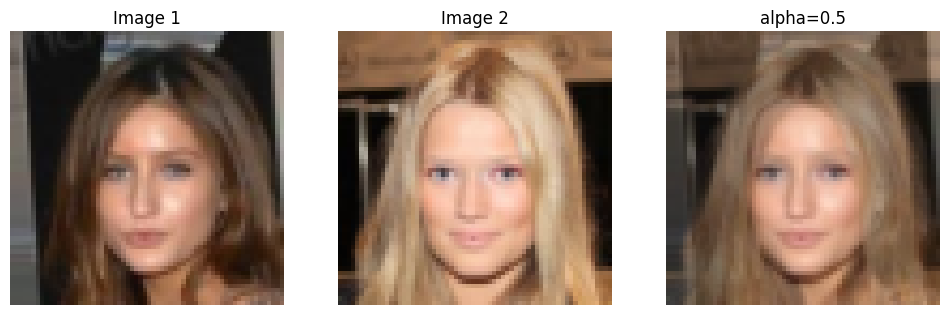

In [10]:
# My code goes here

idx1 = torch.randint(0, len(training_data), (1,)).item()
idx2 = torch.randint(0, len(training_data), (1,)).item()

x1 = training_data[idx1][0]
x2 = training_data[idx2][0]

alpha = 0.5
mix = torch.clamp(alpha * x1 + (1 - alpha) * x2, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x1.permute(1, 2, 0))
axes[0].set_title("Image 1")
axes[0].axis("off")

axes[1].imshow(x2.permute(1, 2, 0))
axes[1].set_title("Image 2")
axes[1].axis("off")

axes[2].imshow(mix.permute(1, 2, 0))
axes[2].set_title(f"alpha={alpha}")
axes[2].axis("off")

plt.show()


In [11]:
# Your explanation goes here:

# We mixed the two images directly by averaging their pixels (with a weight).
# The output usually looks blurry, kind of like two faces on top of each other,
# because the body parts in the two images aren’t in the same pixel locations.
# So instead of getting a “new realistic face”, we mostly get an unnatural blend.
# I guess that's why it’s usually better to interpolate in the latent space,
# where the model’s representation is smoother and the change looks more natural.

## Question 3. VAE Foundations (15 %)


Let us start by recalling the analytical derivation of the VAE.


The simplest version of VAE is comprised of an encoder-decoder architecture.
The *encoder* is a neural network which its input is a datapoint $x$, its output is a hidden representation $z$, and it has weights and biases $\theta$. We denote the encoder's mapping by $P_{\theta}(z|x)$. The *decoder* is another neural network which its input is the data sample $z$, its output is the reconstructed input $x$, and its parameters $\phi$. Hence, we denote the decoder's mapping by $P_{\phi}(x|z)$.

The goal is to determine a posterior distribution $P_{\theta}(z|x)$ of a latent variable $z$ given some data evidence $x$. However, determining this posterior distribution is typically computationally intractable, because according to Bayes:

$(1)$ $P(z|x) = \frac{P(x|z)P(z)}{P(x)}$

The term $P(x)$ is called the evidence, and we can calculate it by marginalization on the latent variable:

$P(x) = \int_{z}P(x|z)P(z)dz$

Unfortunately, this term is intractable because it requires computation of the integral over the entire latent space $z$. To bypass this intractability problem we approximate the posterior distribution with some other distribution $q(z|x_i)$. This approximation is made by the KL-divergence:

$(2)$ $D_{KL}\big(q(z|x_i)||P(z|x_i)\big) = \int_{z}q(z|x_i)\cdot\log\big(\frac{q(z|x_i)}{P(z|x_i)}\big)dz = -\int_{z}q(z|x_i)\cdot\log\big(\frac{P(z|x_i)}{q(z|x_i)}\big)dz \geq 0$

Applying Bayes’ theorem to the above equation yields,

$(3)$ $D_{KL}\big(q(z|x_i)||P(z|x_i)\big) = -\int_{z}q(z|x_i)\cdot\log\big(\frac{P(x_i|z)P(z)}{q(z|x_i)P(x_i)}\big)dz \geq 0$

This can be broken down using laws of logarithms, yielding,

$(4)$ $-\int_{z}q(z|x_i)\cdot\big[\log\big(\frac{P(x_i|z)P(z)}{q(z|x_i)}\big)-\log(P(x_i))\big]dz \geq 0$

Distributing the integrand then yields,

$(5)$ $-\int_{z}q(z|x_i)\cdot\log\big(\frac{P(x_i|z)P(z)}{q(z|x_i)}\big)dz+\int_{z}q(z|x_i)\log(P(x_i))dz \geq 0$

In the above, we note that $log(P(x))$ is a constant and can therefore be pulled out of the second integral above, yielding,

$(6)$ $-\int_{z}q(z|x_i)\cdot\log\big(\frac{P(x_i|z)P(z)}{q(z|x_i)}\big)dz+\log(P(x_i))\int_{z}q(z|x_i)dz \geq 0$

And since $q(z|x_i)$ is a probability distribution it integrates to 1 in the above equation, yielding,

$(7)$ $-\int_{z}q(z|x_i)\cdot\log\big(\frac{P(x_i|z)P(z)}{q(z|x_i)}\big)dz+\log(P(x_i)) \geq 0$

Then carrying the integral over to the other side of the inequality, we get,

$(8)$ $\log(P(x_i)) \geq \int_{z}q(z|x_i)\cdot\log\big(\frac{P(x_i|z)P(z)}{q(z|x_i)}\big)dz$

<!-- Applying rules of logarithms, we get,

$(9)$ $\log(P(x)) \geq \int_{z}q(z|x)\cdot\big[\log\big(P(x|z)\big)+\log\big(P(z)\big)-\log\big(q(z|x)\big)\big]dz$

Recognizing the right hand side of the above inequality as Expectation, we write,

$(10)$ $\log(P(x)) \geq E_{~q(z|x)}\big[\log\big(P(x,z)\big)-\log\big(q(z|x)\big)\big]dz$ -->

From Equation $(8)$ it follows that:

$(9)$ $\log(P(x_i)) \geq \int_{z}q(z|x_i)\cdot\log\big(\frac{P(z)}{q(z|x_i)}\big)dz + \int_{z}q(z|x_i)\cdot\log\big(P(x_i|z)\big)dz$

Which is equivalent to:

$(10)$ $\log(P(x_i)) \geq -D_{KL}\big(q(z|x_i)||P(z)\big) + E_{~q(z|x_i)}\big[\log\big(P(x_i|z)\big)\big]$



The right hand side of the above equation is the Evidence Lower BOund (ELBO). Its bounds $\log(P(x))$ which is the term we seek to maximize. Therefore, maximizing the ELBO maximizes the log probability of our data.


### Part (a) -- 5%
 A we see above, the $ELBO = -D_{KL}\big(q(z|x_i)||P(z)\big) + E_{~q(z|x_i)}\big[\log\big(P(x_i|z)\big)\big]$ is comprised of 2 terms. Explain the meaning of each one of them in terms of a loss function.



In [12]:
# Write your explanation here

# The ELBO has two parts, and when we train a VAE we usually maximize the ELBO
# (or equivalently minimize the negative ELBO, which becomes the loss).

# Reconstruction term (the expected log probability of the input given the latent):
# This measures how well the decoder can reconstruct the input image from the sampled latent code.
# In “loss” form, we take the negative of it, so it becomes a reconstruction loss
# (for images it’s often Binary Cross-Entropy if pixels are in [0,1], or Mean Squared Error depending on the model).
# Better reconstructions → smaller reconstruction loss.

# KL divergence term (between the encoder distribution and the prior):
# This is a regularization term that forces the encoder’s latent distribution to stay close to a simple prior (usually a standard normal).
# In loss form, we add the KL term (because ELBO has a minus KL), so it penalizes the model when the latent codes drift too far from the prior.
# This keeps the latent space smooth/organized and makes it possible to generate new samples by sampling from the prior.

# So overall: reconstruction loss makes outputs match inputs, and KL regularization makes the latent space structured and generative.

### Part (b) -- 10%

 As we saw in class, in traditional variational autoencoder we assume:

$P(z)$ ~ $N(\mu_p,\sigma_{p}^2) = \frac{1}{\sqrt{2\pi\sigma_{p}^2}}\exp\big(-\frac{(z-\mu_p)^2}{2\sigma_{p}^2}\big)$

and

$q(z|x)$ ~ $N(\mu_q,\sigma_{q}^2) = \frac{1}{\sqrt{2\pi\sigma_{q}^2}}\exp\big(-\frac{(z-\mu_q)^2}{2\sigma_{q}^2}\big)$

Assume $\mu_p = 0$ and $\sigma_{p}^2 = 1$. Show that:

$ -D_{KL}\big(q(z|x_i)||P(z)\big) = \frac{1}{2}\big[1+\log(\sigma_{q}^2)-\sigma_{q}^2-\mu_q^2\big]$



**WRITE YOUR SOLUTIUON HERE**. (You can also upload your solution as an image.)
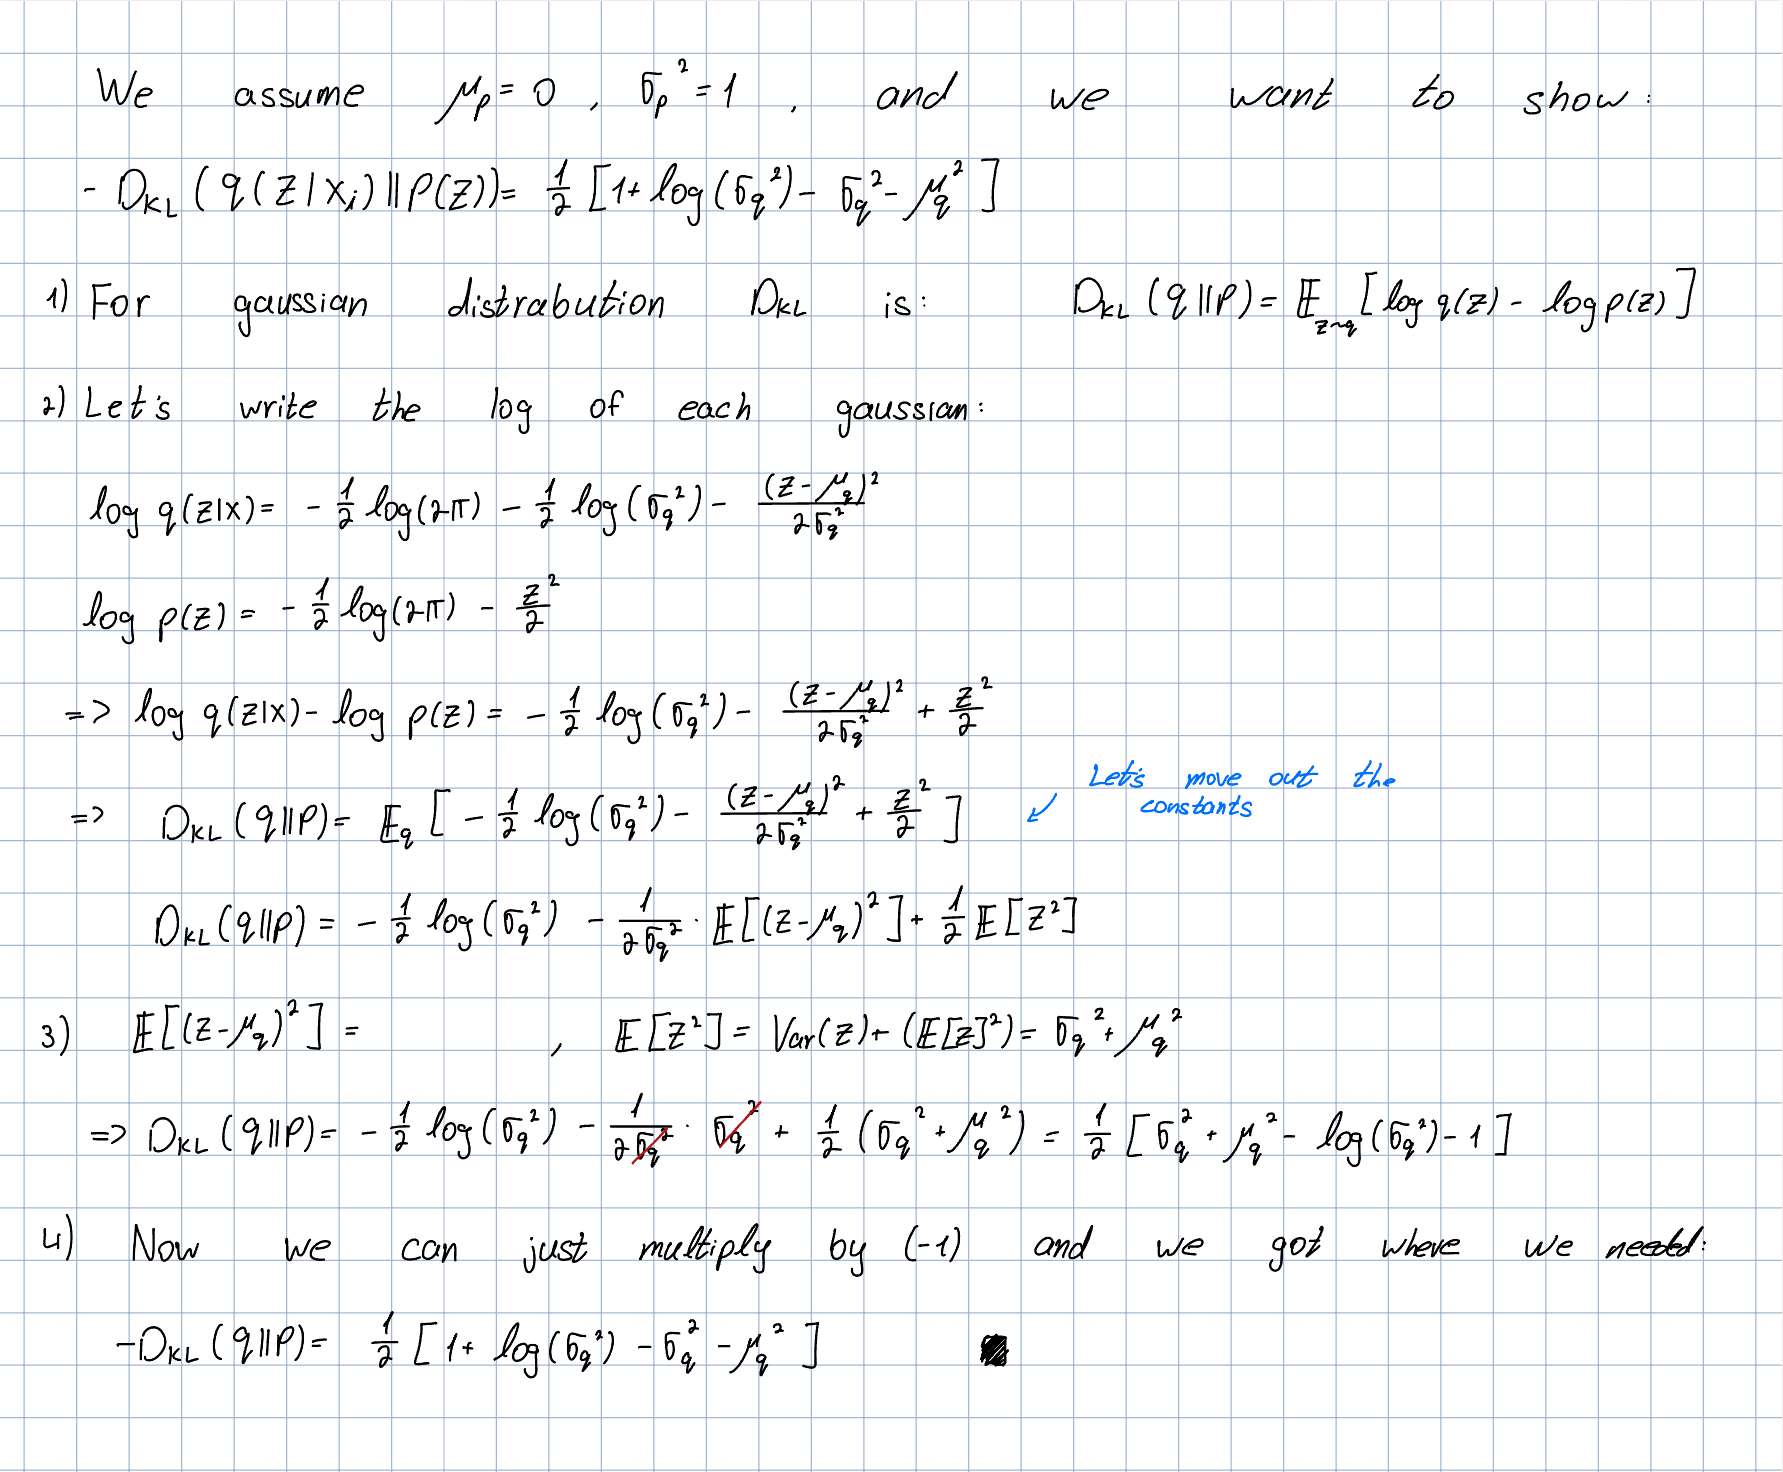



**Minimizing** the loss function, over a batch in the dataset now can be written as:

$\mathcal{L(\theta,\phi)} = -\sum_j^J\bigg(\frac{1}{2}\big[1+\log(\sigma_{q_j}^2)-\sigma_{q_j}^2-\mu_{q_j}^2\big]\bigg) - \frac{1}{M}\sum_i^M\bigg(E_{~q_{\theta}(z|x_i)}\big[\log\big(P_{\phi}(x_i|z)\big)\big]\bigg)$

where $J$ is the dimension of the latent vector $z$ and $M$ is the number of samples stochastically drawn from the dataset.

## Question 4. VAE Implementation (25 %)

As seen in class, a suitable way to extract features from dataset of images is by convolutional neural network (CNN). Hence, here you will build a convolutional VAE.
\
The basic idea is to start from full resolution images, and by convolutional kernels extract the important features of the dataset. Remember that the output of the VAE should be in the same dimensions $(H_1,W_1,C_1)$ as the input images.

**The encoder** should be comprised of convolutional layers (nn.Conv2d). Recall that the dimension of the input images is changing according to:

$Z = \bigg(H_2(=\frac{H_1-F+2P}{S}+1),W_2(=\frac{W_1-F+2P}{S}+1),C_2\bigg)$

where $S$ is the stride, $F$ is the kernel size, $P$ is the zero padding and $C_2$ is the selected output channels. $Z$ is the output image.

**The decoder** should reconstruct the images from the latent space. In order to enlarge dimensions of images, your network should be comprised of transposed convolutional layers (nn.ConvTranspose2d). See the following images of the operation of transpose convolution to better understand the way it works.




***Transposed Convolution with Stride = 1***

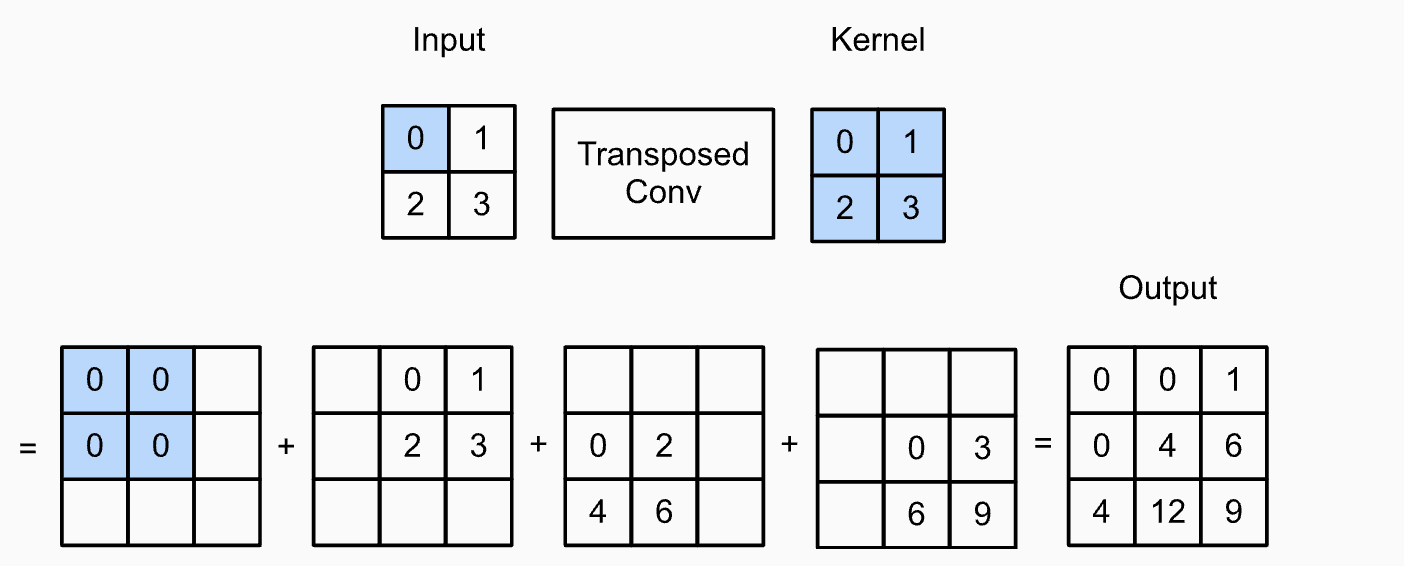

***Transposed Convolution with Stride = 2***
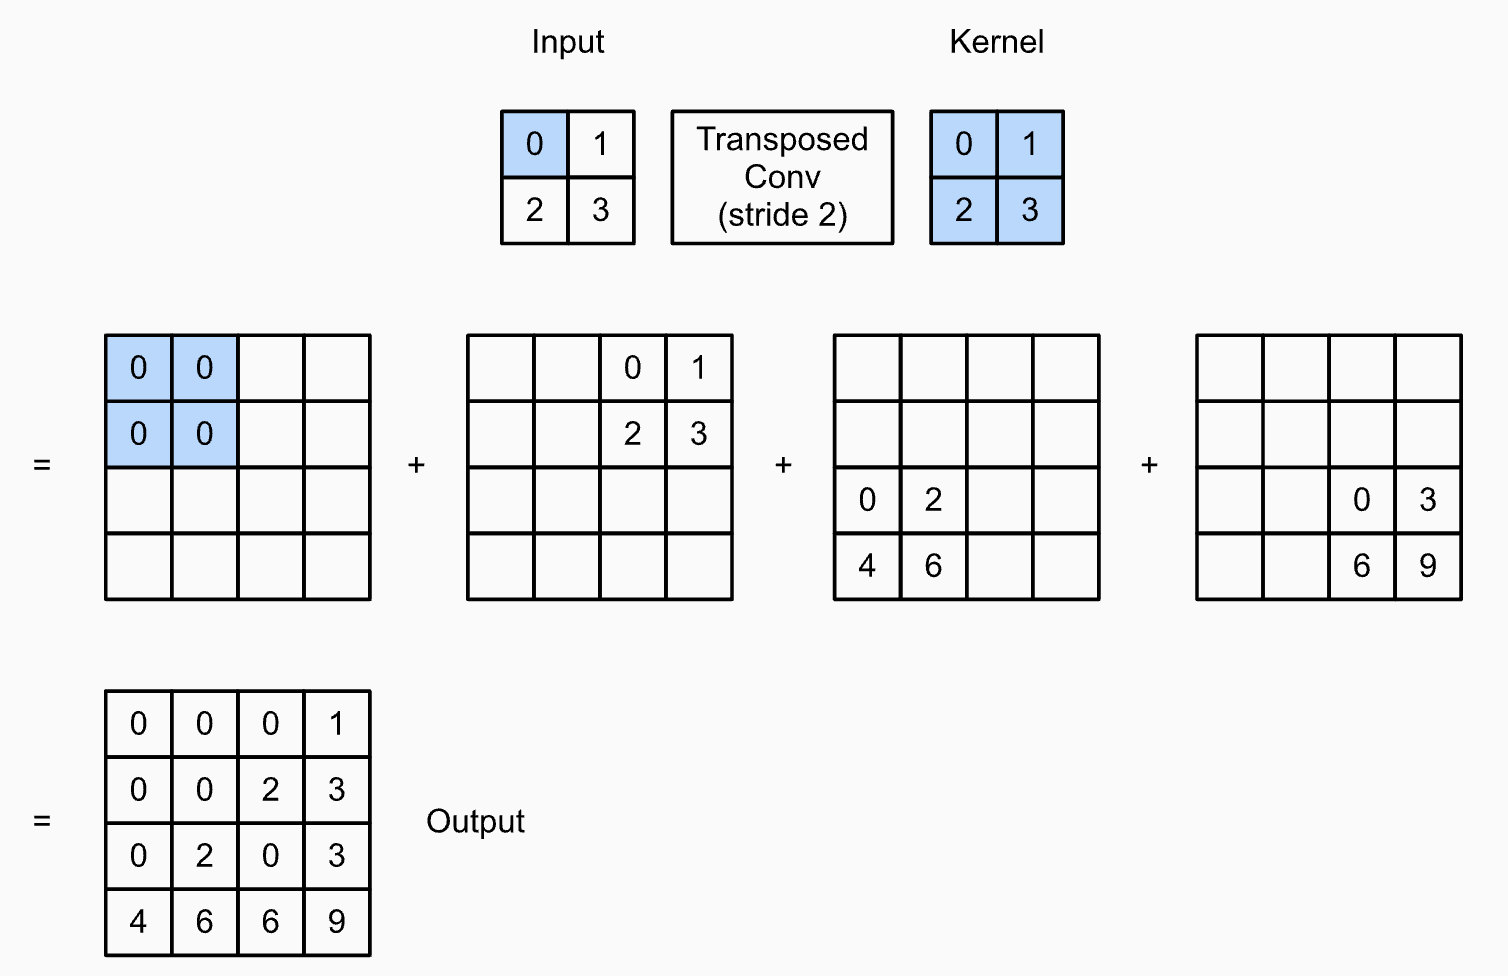

The architecture of your VAE network should be in the following form:


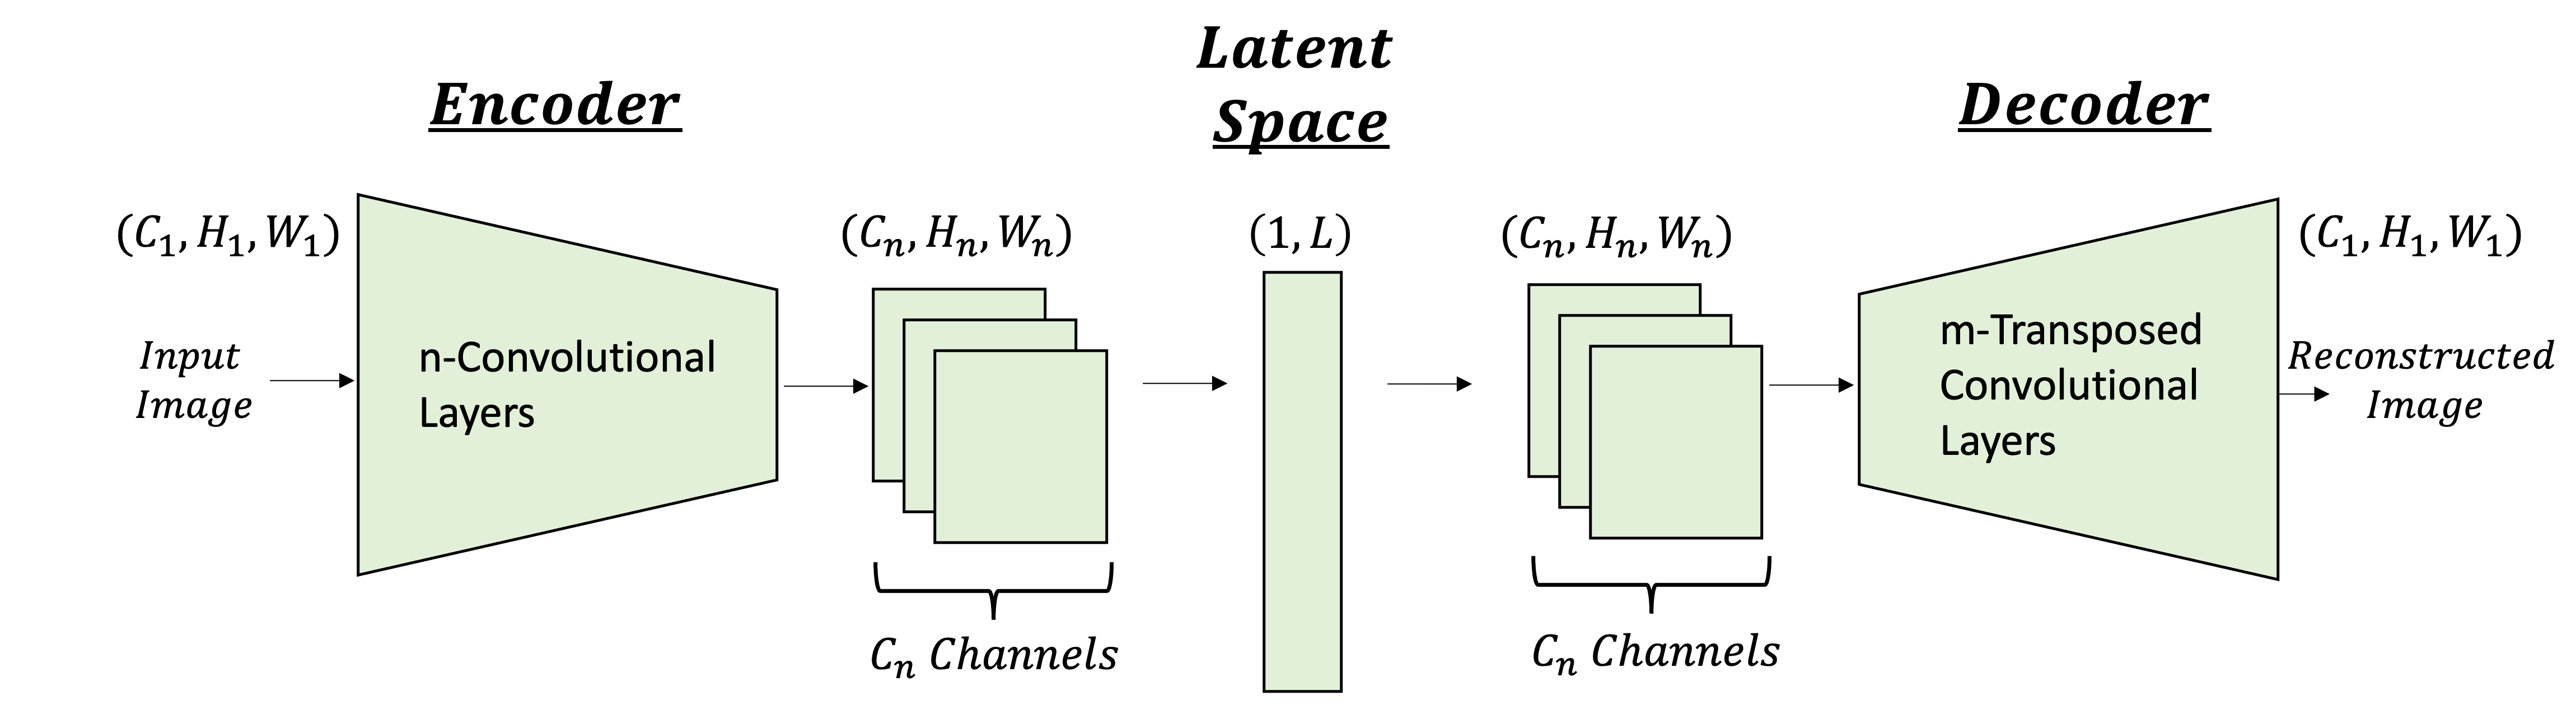

### Part (a) -- 7%

 **Encoder**

Here, you will implement the architecture of the encoder.

The encoder should consist of 4 Blocks as follows:

BLOCK 1:
- Convolutional layer (nn.Conv2D(in_channels, num_hidden, kernel_size=(3,3), stride=(2,2)))
- Batch Normalization(num_hidden)
- Activation Function: nn.ReLU()

BLOCK 2:
- Convolutional layer (nn.Conv2D(num_hidden, num_hidden * 2, kernel_size=(3,3), stride=(2,2))
- Batch Normalization(num_hidden * 2)
- Activation Function: nn.ReLU()

BLOCK 3:
- Convolutional layer (nn.Conv2D(num_hidden * 2, num_hidden * 4, kernel_size=(3,3), stride=(2,2))
- Batch Normalization(num_hidden * 4)
- Activation Function: nn.ReLU()

BLOCK 4:
- Convolutional layer (nn.Conv2D(num_hidden * 4, num_hidden * 8, kernel_size=(3,3), stride=(2,2))
- Batch Normalization(num_hidden * 8)
- Activation Function: nn.ReLU()

In addidion to the 4 Blocks, you should add the following linear layers:

Linear $\mu$:
- nn.Linear( ___ ,latent).

Linear $\log(\sigma)$:
- nn.Linear( ___ ,latent).

**NOTES:**

- The input of the linear layer should be according to the size of the images you picked in the transformation part. (If you did resize the images)

- Consider using Padding in the convolutional layers to correct mismatches in sizes.

- In the forward function, you will have to reshape the output from the 4'th block to $(H_4\cdot W_4\cdot C_4 , latent)$, where $H_4$ is the height of the output image from the 4'th block, $W_4$ is the width of the output image from the 4'th block and $C_4$ is num_hidden*8 (number of channels of the output image from the 4'th block).

**You can change any parameter of the network to suit your code - this is only a recommendation.**

In [13]:
class Encoder(nn.Module):
    def __init__(self, in_channels, num_hiddens, latent):
        super(Encoder, self).__init__()
        # YOUR CODE GOES HERE:

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, num_hiddens, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(num_hiddens),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(num_hiddens, num_hiddens * 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(num_hiddens * 2),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(num_hiddens * 2, num_hiddens * 4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(num_hiddens * 4),
            nn.ReLU()
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(num_hiddens * 4, num_hiddens * 8, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(num_hiddens * 8),
            nn.ReLU()
        )

        fc_in = (num_hiddens * 8) * 4 * 4
        self.fc_mu = nn.Linear(fc_in, latent)
        self.fc_logvar = nn.Linear(fc_in, latent)

    def forward(self, inputs):
        # YOUR CODE GOES HERE:

        x = self.block1(inputs)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

**Notice: We output $\log\sigma$ and not $\sigma^2$, this is a convention when training VAEs but it is completely equivalent.**

### Part (b) -- 7%
 **Decoder**

Here, you will implement the architecture of the decoder.

First, Apply a linear layer to the input of the decoder as follows:

- nn.Linear(latent, ___ ).

The output of the linear layer should match to $H_4\cdot W_4\cdot C_4$, which were the same parameters from the encoder 4'th block's output.

Then, the decoder should consist of 4 Blocks as follows:

BLOCK 1:
- Transposed Convolutional layer (nn.ConvTranspose2d(in_channels, num_hidden // 2, kernel_size=(4,4), stride=(2,2)))
- Batch Normalization(num_hidden // 2)
- Activation Function: nn.ReLU() or nn.LeakyReLU()

BLOCK 2:
- Transposed Convolutional layer (nn.ConvTranspose2d(num_hidden // 2, num_hidden // 4, kernel_size=(4,4), stride=(2,2)))
- Batch Normalization(num_hidden // 4)
- Activation Function: nn.ReLU() or nn.LeakyReLU()

BLOCK 3:
- Transposed Convolutional layer (nn.ConvTranspose2d(num_hidden // 4, num_hidden // 8, kernel_size=(4,4), stride=(2,2)))
- Batch Normalization(num_hidden // 8)
- Activation Function: nn.ReLU() or nn.LeakyReLU()

BLOCK 4:
- Transposed Convolutional layer (nn.ConvTranspose2d(num_hidden // 8, num_hidden // 8, kernel_size=(4,4), stride=(2,2)))
- Batch Normalization(num_hidden // 8)
- Activation Function: nn.ReLU() or nn.LeakyReLU()


Afterwards, we should generate an image in the same size as our input images. Thus add 1 more block consisting of:

BLOCK 5:
 - nn.Conv2d(num_hiddens//8, out_channels=3,kernel_size=(3,3), stride=(1,1), padding=(1,1)),
 - Activation function.

**NOTES:**

- The output of the linear layer should be according to the size of the images you picked in the transformation part. (If you did resize the images)

- Consider using Padding in the  transposed convolutional layers to correct mismatches in sizes.

- In the forward function, you will have to reshape the output of the linear layer to ($Batch, H_4, W_4, C_4$)

- The output of the decoder should be of values in $[0,1]$.



**You can change any parameter of the network to suit your code, this is only a recommendation.**

In [14]:
class Decoder(nn.Module):
    def __init__(self, in_channels, num_hiddens,latent):
        super(Decoder, self).__init__()
        # YOUR CODE GOES HERE:

        self.num_hiddens = num_hiddens
        c4 = num_hiddens * 8
        self.fc_dec = nn.Linear(latent, c4 * 4 * 4)

        self.block1 = nn.Sequential(
            nn.ConvTranspose2d(c4, c4 // 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c4 // 2),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(
            nn.ConvTranspose2d(c4 // 2, c4 // 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c4 // 4),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(
            nn.ConvTranspose2d(c4 // 4, c4 // 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c4 // 8),
            nn.ReLU()
        )
        self.block4 = nn.Sequential(
            nn.ConvTranspose2d(c4 // 8, c4 // 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(c4 // 8),
            nn.ReLU()
        )
        self.block5 = nn.Sequential(
            nn.Conv2d(c4 // 8, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        # YOUR CODE GOES HERE:

        x = self.fc_dec(inputs)
        x = x.view(x.size(0), self.num_hiddens * 8, 4, 4)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x_rec = self.block5(x)

        return x_rec

### Part (c) -- 4%
**VAE Model**

Once you have the architecture of the encoder and the decoder, we want to put them together and train the network end-to-end.

Remember that in VAEs, you need to sample from a gaussian distribution at the input of the decoder. In order to backpropagate through the network, we use the reparametrization trick. The reparametrization trick is saying that sampling from $𝑧∼N(\mu,\sigma)$ is equivalent to sampling $\varepsilon∼N(0,1)$ and setting $𝑧=\mu+\sigma⊙\varepsilon$. Where, epsilon is an input to the network while keeping your sampling operation differentiable.
The reparametrization function is given to you in the VAE class.

Here, you should write the *forward()* function and to combine all the model's settings to a final network.

In [15]:
class VAE(nn.Module):
    def __init__(self, enc_in_chnl,enc_num_hidden,dec_in_chnl,dec_num_hidden,latent):
        super(VAE, self).__init__()
        self.encode = Encoder(in_channels=enc_in_chnl, num_hiddens=enc_num_hidden,latent = latent)
        self.decode = Decoder(in_channels=dec_in_chnl, num_hiddens=dec_num_hidden,latent = latent)

    # Reparametrization Trick
    def reparametrize(self, mu, logvar):
      std = torch.exp(0.5 * logvar)
      eps = torch.randn_like(std)
      return eps.mul(std).add_(mu)

    # Initialize Weights
    def weight_init(self, mean, std):
        for m in self._modules:
            if isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Conv2d):
                m.weight.data.normal_(mean, std)
                m.bias.data.zero_()

    def forward(self, x):
        # YOUR CODE GOES HERE:

        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        x_rec = self.decode(z)

        return x_rec , mu, logvar

### Part (d) -- 7%

**Loss Function**

As we saw earlier, the loss function is based on the ELBO; Over a batch in the dataset, it can be written as:

$\mathcal{L(\theta,\phi)} = -\sum_j^J\bigg(\frac{1}{2}\big[1+\log(\sigma_{q_j}^2)-\sigma_{q_j}^2-\mu_{q_j}^2\big]\bigg) - \frac{1}{M}\sum_i^M\bigg(E_{~q_{\theta}(z|x_i)}\big[\log\big(P_{\phi}(x_i|z)\big)\big]\bigg)$

where $J$ is the dimension of the latent vector $z$ and $M$ is the number of samples stochastically drawn from the dataset.

**$\beta$-Variational Autoencoder ($\beta$-VAE)**

As seen in class, the fact that the ELBO is comprised of the sum of two loss terms implies that these can be balanced using an additional hyperparameter $\beta$, i.e.,

$\beta\cdot D_{KL}\big(q(z|x_i)||P(z)\big) - E_{~q(z|x_i)}\big[\log\big(P(x_i|z)\big)\big]$

It is highly recommended to use the $\beta$-loss for increasing performance.



Explain what could be the purpose of the hyperparameter $\beta$ in the loss function? If $\beta = 1$ is same as VAE, What is the effect of $\beta \neq 1$?

In [16]:
# Write your explanation here

# beta is a weight that controls the trade-off between the two parts of the VAE loss:
# the KL regularization term - how strong is the force that the latent distribution matches the prior,
# and the reconstruction term - how accurately reconstruct the input.

# Beta=1 As writen above, same as VAE.

# Beta>1 keep the latent space close to the prior → typically a more disentangled latent space and better sampling,
# but often worse reconstructions (more blurry) because the model is more constrained.

# Beta <1 reduces the KL wight, means better reconstructions but a less regular latent space,
# which can damage smooth sampling and can make generations less reliable.

Here you should write specifically the code for the loss function.


In [17]:
beta = 0.1
def vae_loss(x_recon, x, mu, logvar):
    # YOUR CODE GOES HERE....

    BCE = F.binary_cross_entropy(x_recon, x, reduction='sum') # I want to try both: binary_cross_entropy and mse_loss
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE, KLD*beta

 Here, define all the hyperparameters values for the training process.

We gave you recommended values for the VAE model. You can modify and change it to suit your code better if needed.

In [18]:
learning_rate = 1e-4
batch_size = 64
num_epochs = 20
dataset_size = 30000 # How many data samples to use for training, 30,000 should be enough.

#VAE Class inputs:
enc_in_chnl = 3
enc_num_hidden = 32
dec_in_chnl = 32 # Original 256
dec_num_hidden = 32 # Original 256

In [19]:
train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Question 5. VAE Training (15 %)



### Part (a) -- 4%
Complete the training function below

In [20]:
def train(num_epochs,batch_size,dataset_size,model):
    '''
    This is a starter code for the training process. You can modify it for your
    own conveinient.
    num_epochs - number of training epochs
    batch_size - size of the batches
    dataset_size - How many training samples to use.
    model - The model you are training.

    Note: decide what are the outputs of the function.
    '''

    # Your code goes Here:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    train_losses = []
    val_losses = []


    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
          imgs, _ = batch
          imgs = imgs.to(device)

          #apply model:
          recon_batch, mu, logvar = model(imgs)

          #calculate loss:
          bce, kld = vae_loss(recon_batch, imgs, mu, logvar)
          loss = (bce + kld) / imgs.size(0)

          # optimization:
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          running_loss += loss.item()

          # Limit dataset size if requested
          if (batch_idx + 1) * batch_size >= dataset_size:
              break

        avg_train_loss = running_loss / (batch_idx + 1)
        train_losses.append(avg_train_loss)


        # Validation set
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for imgs_val, _ in test_loader:
                imgs_val = imgs_val.to(device)
                recon_val, mu_val, logvar_val = model(imgs_val)
                bce_v, kld_v = vae_loss(recon_val, imgs_val, mu_val, logvar_val)
                val_loss = (bce_v + kld_v) / imgs_val.size(0)
                val_running_loss += val_loss.item()

        avg_val_loss = val_running_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        print(f'Epoch {epoch}: Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f} ')


    return model, train_losses, val_losses


### Part (b) -- 4%  

We first train with dimension of latent space $L=3$

We recommend to use *weight_init()* function, which helps stabilize the training process.

In [21]:
latent1 = 3

if torch.cuda.is_available():
    model_1 = VAE(enc_in_chnl,enc_num_hidden,dec_in_chnl,dec_num_hidden,latent1).cuda()
    model_1.weight_init(mean=0, std=0.02)
else:
    model_1 = VAE(enc_in_chnl,enc_num_hidden,dec_in_chnl,dec_num_hidden,latent1)
    model_1.weight_init(mean=0, std=0.02)

optimizer = torch.optim.Adam(model_1.parameters(), lr=learning_rate)

Train your model, plot the train and the validation loss graphs. Explain what is seen.

In [22]:
import torch.nn.functional as F

vae, train_loss_lst, val_loss_lst = train(num_epochs, batch_size, dataset_size, model_1)


Epoch 0: Train Loss: 7229.1607, Validation Loss: 7053.0068 
Epoch 1: Train Loss: 7081.1729, Validation Loss: 7027.2068 
Epoch 2: Train Loss: 7058.9307, Validation Loss: 7017.6810 
Epoch 3: Train Loss: 7063.9331, Validation Loss: 7014.7105 
Epoch 4: Train Loss: 7070.0623, Validation Loss: 7007.9440 
Epoch 5: Train Loss: 7054.9141, Validation Loss: 7006.4688 
Epoch 6: Train Loss: 7051.8795, Validation Loss: 7002.6379 
Epoch 7: Train Loss: 7054.1963, Validation Loss: 7001.5094 
Epoch 8: Train Loss: 7049.7136, Validation Loss: 7006.0682 
Epoch 9: Train Loss: 7050.0966, Validation Loss: 7005.6520 
Epoch 10: Train Loss: 7041.0425, Validation Loss: 6997.7882 
Epoch 11: Train Loss: 7042.9387, Validation Loss: 7002.3700 
Epoch 12: Train Loss: 7039.0406, Validation Loss: 6993.3670 
Epoch 13: Train Loss: 7042.2688, Validation Loss: 6997.8054 
Epoch 14: Train Loss: 7041.6248, Validation Loss: 6994.1003 
Epoch 15: Train Loss: 7044.6338, Validation Loss: 6993.6725 
Epoch 16: Train Loss: 7033.8519, V

Visualize, from the test dataset, an original image against a reconstructed image. Has the model reconstructed the image successfully? Explain.

In [23]:
# Your Code Goes Here

def compare_images(original, reconstruction):
    # Normalize images
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original.permute(1, 2, 0)) # Change from (C,H,W) to (H,W,C)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("VAE Reconstruction Image")
    plt.imshow(reconstruction.permute(1, 2, 0))
    plt.axis('off')

    plt.show()

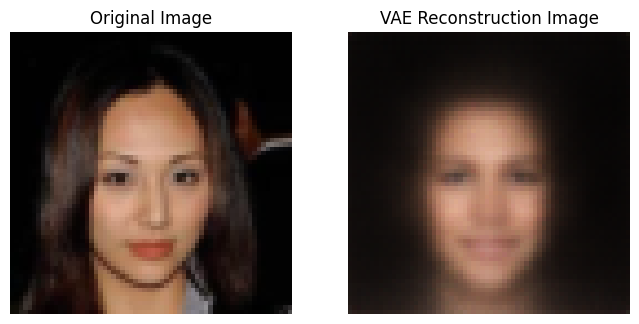

In [24]:
idx = random.randint(0, len(test_data)-1)
image_tensor, _ = test_data[idx]

# 1. Ensure the model is in evaluation mode
model_1.eval()

# 2. Move model and image to the same device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_1.to(device)

# 3. Prepare the image (add batch dimension and move to device)
# Assume 'img_tensor' is your randomly picked [3, 64, 64] image
input_tensor = image_tensor.unsqueeze(0).to(device)

# 4. Apply the model without calculating gradients (saves memory)
with torch.no_grad():
    # Forward pass: x_rec is the reconstructed image
    x_rec, mu, logvar = model_1(input_tensor)

# 5. Bring the result back to CPU and remove batch dimension for plotting
reconstructed_img = x_rec.squeeze(0).cpu()

compare_images(image_tensor, reconstructed_img)

### Part (c) -- 7%  

Next, we train with larger $L > 3$

Based on the results for $L = 3$, choose a larger $L$ to improve your results.
Train new model with your choice for $L$.

In [25]:
latent2 = 32 # TO DO: Choose latent space dimension.

if torch.cuda.is_available():
    model_2 = VAE(enc_in_chnl,enc_num_hidden,dec_in_chnl,dec_num_hidden,latent2).cuda()
    model_2.weight_init(mean=0, std=0.02)
else:
    model_2 = VAE(enc_in_chnl,enc_num_hidden,dec_in_chnl,dec_num_hidden,latent2)
    model_2.weight_init(mean=0, std=0.02)

vae_2, train_loss_lst_2, val_loss_lst_2 = train(num_epochs, batch_size, dataset_size, model_2)

Epoch 0: Train Loss: 6814.3995, Validation Loss: 6455.0069 
Epoch 1: Train Loss: 6440.2287, Validation Loss: 6382.6692 
Epoch 2: Train Loss: 6397.7489, Validation Loss: 6348.1410 
Epoch 3: Train Loss: 6372.8650, Validation Loss: 6335.1587 
Epoch 4: Train Loss: 6372.5381, Validation Loss: 6327.7333 
Epoch 5: Train Loss: 6360.6145, Validation Loss: 6326.3477 
Epoch 6: Train Loss: 6374.6855, Validation Loss: 6320.6332 
Epoch 7: Train Loss: 6353.7249, Validation Loss: 6314.8500 
Epoch 8: Train Loss: 6356.2691, Validation Loss: 6315.8211 
Epoch 9: Train Loss: 6347.7166, Validation Loss: 6316.0385 
Epoch 10: Train Loss: 6341.7478, Validation Loss: 6314.3211 
Epoch 11: Train Loss: 6340.7449, Validation Loss: 6304.0617 
Epoch 12: Train Loss: 6342.1377, Validation Loss: 6301.7410 
Epoch 13: Train Loss: 6336.7704, Validation Loss: 6302.7768 
Epoch 14: Train Loss: 6339.2659, Validation Loss: 6300.9525 
Epoch 15: Train Loss: 6327.3612, Validation Loss: 6296.8469 
Epoch 16: Train Loss: 6329.8111, V

Plot the train and the validation loss graphs. Explain what is seen.

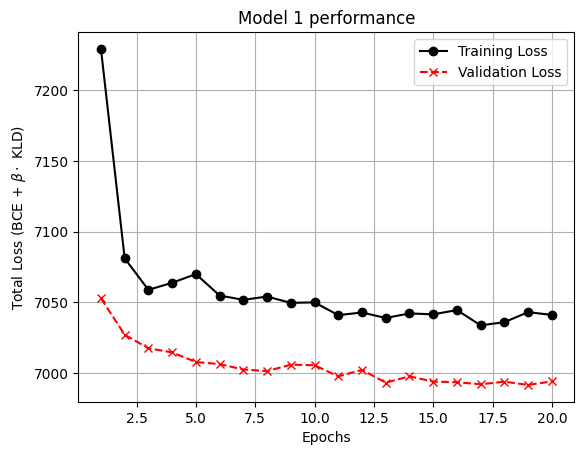

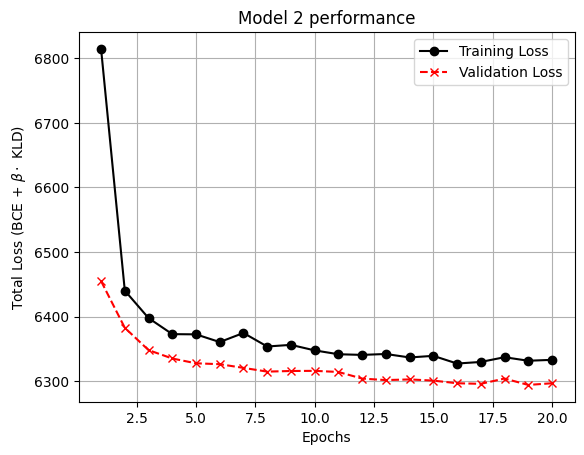

In [26]:
# Your Code Goes Here

def plot_learning_curves(train_loss, val_loss, title=""):
    """
    Plots the training and validation loss curves.
    """
    epochs = range(1, len(train_loss) + 1)

    # Create the plot
    plt.plot(epochs, train_loss, label='Training Loss', color='black', marker='o')
    plt.plot(epochs, val_loss, label='Validation Loss', color='red', linestyle='--', marker='x')

    # Add labels and title
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Total Loss (BCE + $\\beta \\cdot$ KLD)')
    plt.legend()
    plt.grid(True)
    plt.title(title)
    # Save and show
    plt.savefig('training_curves.png')
    plt.show()

# Plot for Model 1
plot_learning_curves(train_loss_lst, val_loss_lst, "Model 1 performance")

# Plot for Model 2
plot_learning_curves(train_loss_lst_2, val_loss_lst_2, "Model 2 performance")

Visualize, from the test dataset, an original image against a reconstructed image. Has the model reconstructed the image successfully? Are the images identical? Explain.

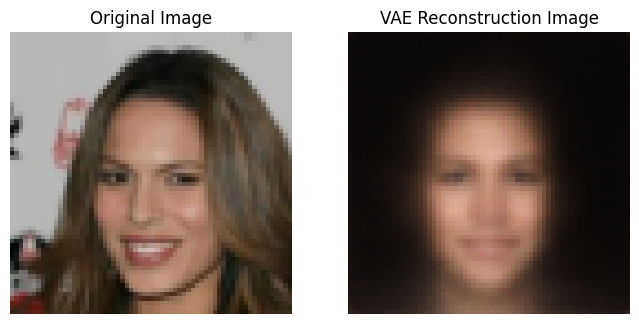

In [27]:
# Your Code Goes Here

idx_2 = random.randint(0, len(test_data)-1)
image_tensor_2, _ = test_data[idx_2]

# Ensure the model is in evaluation mode
model_2.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2.to(device)

# Prepare the image (add batch dimension)
input_tensor_2 = image_tensor_2.unsqueeze(0).to(device)

with torch.no_grad():
    # Forward pass: x_rec is the reconstructed image
    x_rec_2, mu_2, logvar_2 = model_1(input_tensor)

# Bring the result back to CPU and remove batch dimension for plotting
reconstructed_img_2 = x_rec_2.squeeze(0).cpu()

compare_images(image_tensor_2, reconstructed_img_2)

 What will happened if we choose extremely high dimension for the latent space?

In [28]:
# Write your explanation here

# If we choose an extremely high dimension for the latent space,
# it would damage the compression characteristic of the VAE.

# The VAE's goal is to find a compressed representation of the input,
# if it's too large, then the model simply learns the identity function, so input = output
# and we wouldnt get the output we desire


Did you output blurry reconstructed images? If the answer is yes, explain what could be the reason. If you got sharp edges and fine details, explain what you did in order to achieve that.

Note: If you got blurry reconstructed images, just explain why. You dont need to change your code or retrain your model for better results (as long as your results can be interpreted as a human face).


In [29]:
# Blurry reconstructions:
# Yes, reconstructions are blurry. This is because in VAEs the reconstruction loss tends to average pixels,
# and the KL term also regularizes the latent space, which can reduce sharpness (especially with small L or short training).

## Question 6: Generate New Faces (10 %)

Now, for the fun part!

We are going to generate new celebrity faces with our VAE models. A function for new faces generation is given to you. Modify it (if needed) to fit your code.



In [30]:
# creates random noise sample in the correct shape.
def generate_faces(model, grid_size, latent):
    model.eval()
    dummy = torch.empty([batch_size,latent])
    z = torch.randn_like(dummy).to(device)

    #insert the random noise to the decoder to create new samples.
    sample = model.decode(z)
    new_face_list = []

    j=0
    while j < grid_size:
        new_face_list.append(sample[j])
        j+=1

    # grid = make_grid(new_face_list)
    show(new_face_list)

**Model 1 ($L = 3$) results:**

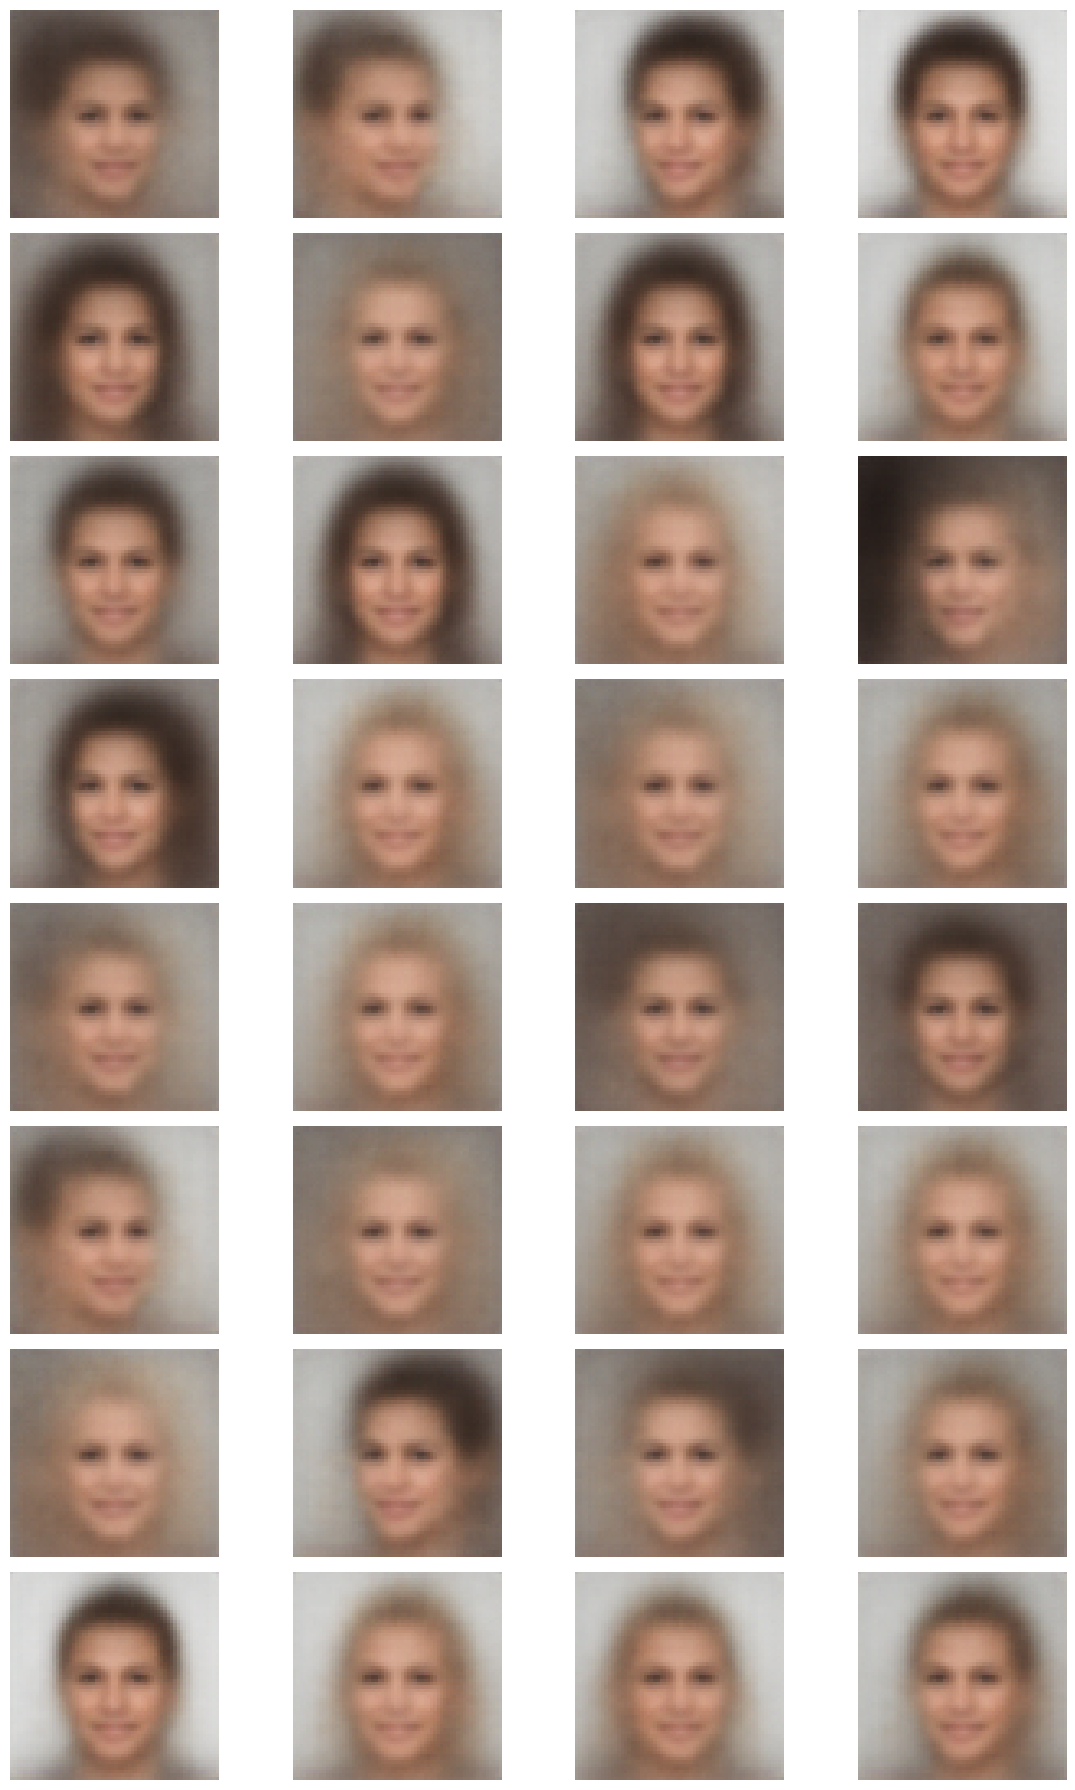

In [31]:
generate_faces(model_1,grid_size=32,latent=latent1)

**Model 2 results:**

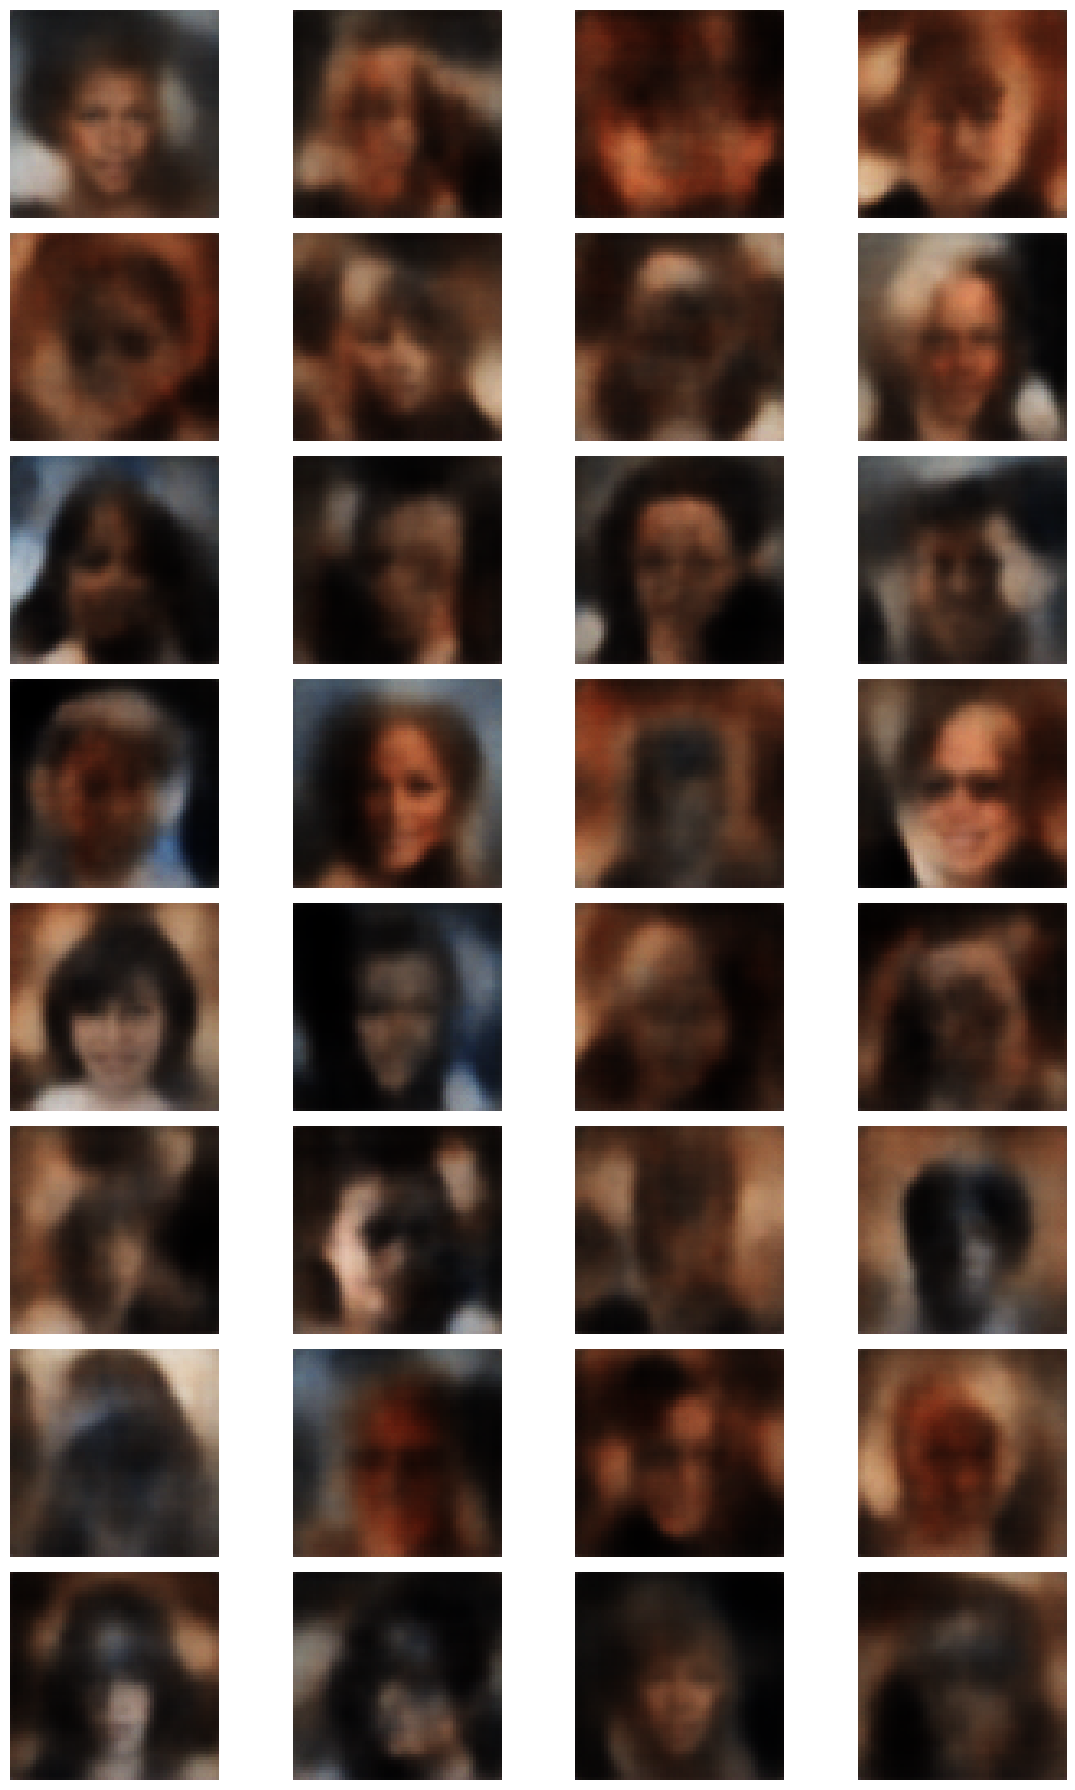

In [32]:
generate_faces(model_2,grid_size=32,latent=latent2)

*Q1:* Generate new faces with VAE model with latent space dimension = 3. Did you get diverse results? What are the most prominent features that the latent space capture?

*Q2:* Generate new faces with VAE model with your decision for latent space dimension. What are the most prominent features that the latent space capture?

*Q3:* What are the differences? Your results are similar to the dataset images? Do you get realistic images for your chosen latent space dimension? If not, change your decision or your network to acheive more realistic results.

In [33]:
#YOUR ANSWERS GO HERE

# Q1 Answer (latent_1 = 3):
# When latent is tiny, the model has to compress a lot of information into a few dimensions,
# so the generated faces look quite similar. It mainly captures coarse features (pose/skin tone/hair),
# but fine details are usually missing.

# Q2 Answer (latent_2 = 32):
# With a larger latent space, the model has more freedom, so the samples are more diverse
# and less “average-pixeling-looking”. They are still not sharp, but variability is clearly higher.

# Q3 Answer:
# The main difference is latent capacity: a larger latent can store more information, so we get more diversity
# and less “mean face” behavior. To improve realism, it would need to be trained longer / using more data,
# or else increase the model capacity (more layers/filters).

## Question 7: Extrapolation (10 %)

Recall that we extrapolate in the images domain in Question 2, part (c).
Here, extrapolate in the latent space domain to generate new images.

Define $\beta = [0, 0.1, 0.2, ... , 0.9, 1]$ and randomly sample from $Z \sim \mathcal{N(0,1)}$ 2 different samples and generate 2 new face images: $X_1, X_2$.

Extrapolate in the latent domain as follows: $\beta_i\cdot Z_1 + (1-\beta_i)\cdot Z_2$ for each $\beta_i \in \beta$.

Plot the extrapolation of the images for each $\beta$ and discuss your results.
Repeat the process for 3 different samples.




--- Sample 1 of 3 ---


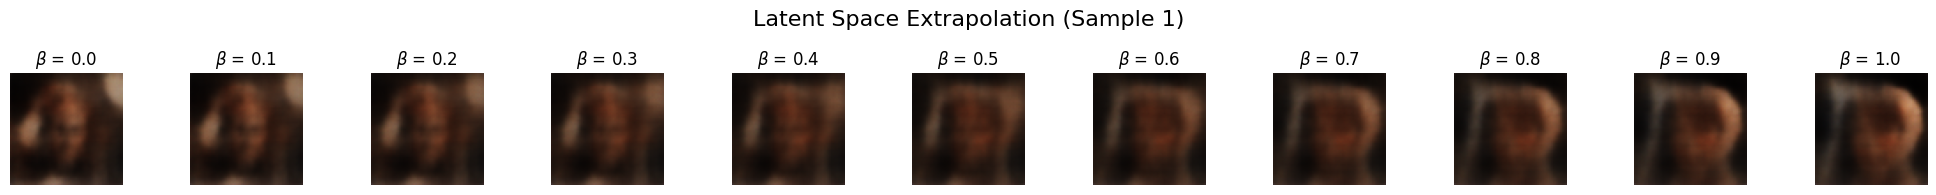


--- Sample 2 of 3 ---


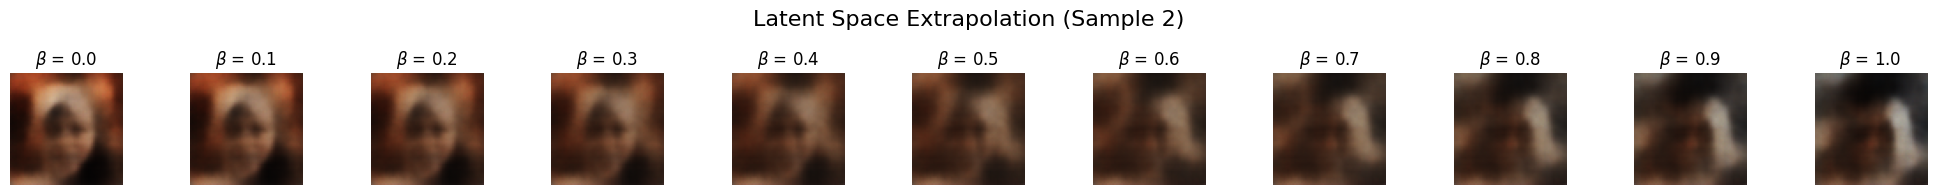


--- Sample 3 of 3 ---


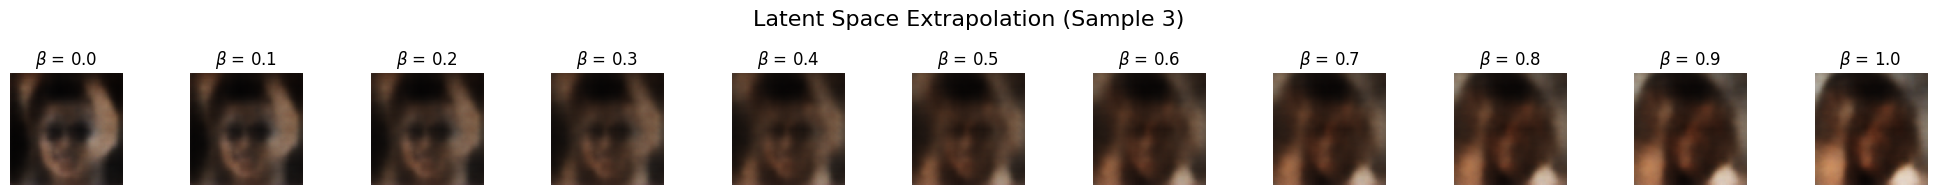

In [34]:
# YOUR CODE GOES HERE

import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2.to(device)
model_2.eval()


beta_values = [i / 10.0 for i in range(11)] # [0.0, 0.1, ..., 1.0]

for sample_idx in range(3):
    print(f"\n--- Sample {sample_idx + 1} of 3 ---")

    # Generate 2 random latent vectors (Z1, Z2) for extrapolation

    z1 = torch.randn(1, latent2).to(device)
    z2 = torch.randn(1, latent2).to(device)

    generated_images = []
    with torch.no_grad():
        for beta_i in beta_values:
            # Extrapolate in the latent space
            z_extrapolated = beta_i * z1 + (1 - beta_i) * z2

            # Generate image from the extrapolated latent vector
            img_generated = model_2.decode(z_extrapolated)
            generated_images.append(img_generated.squeeze(0).cpu())

    # Plot the generated images for this sample
    fig, axes = plt.subplots(1, len(beta_values), figsize=(20, 2))
    fig.suptitle(f'Latent Space Extrapolation (Sample {sample_idx + 1})', fontsize=16)

    for i, img_tensor in enumerate(generated_images):
        ax = axes[i]
        ax.imshow(img_tensor.permute(1, 2, 0)) # Convert (C, H, W) to (H, W, C)
        ax.set_title(r'$\beta$ = ' + f'{beta_values[i]:.1f}')
        ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for subtitle
    plt.show()